In [1]:
from email.utils import encode_rfc2231

import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import polars.selectors as cs
import gc

import numpy as np
from easyocr.model.vgg_model import Model

In [2]:
df_path_csv = r'/home/ubuntu/DataAnalysis/Analysis/Data/datasets/SPAM text message 20170820 - Data.csv'

In [3]:
df = pl.read_csv(df_path_csv)

In [5]:
df.estimated_size('mb')

0.44439220428466797

In [6]:
df.write_parquet(r'/home/ubuntu/DataAnalysis/Analysis/Data/datasets/SPAM text message 20170820 - Data.parquet')

In [9]:
df_path = r'/home/ubuntu/DataAnalysis/Analysis/Data/datasets/SPAM text message 20170820 - Data.parquet'

In [10]:
df = pl.read_parquet(df_path)

In [11]:
df.estimated_size('mb')

0.44439220428466797

In [12]:
df.describe()

statistic,Category,Message
str,str,str
"""count""","""5572""","""5572"""
"""null_count""","""0""","""0"""
"""mean""",null,null
"""std""",null,null
"""min""","""ham""","""#ERROR!"""
"""25%""",null,null
"""50%""",null,null
"""75%""",null,null
"""max""","""spam""","""… we r stayin here an extra we…"


In [14]:
df['Category'].value_counts()

Category,count
str,u32
"""ham""",4825
"""spam""",747


In [27]:
len(df.select(
    pl.col('Message')
).group_by(
    'Message'
).len().filter(
    pl.col('len') > 1
))

289

In [48]:
df.shape[0]

5572

In [52]:
df

Category,Message
str,str
"""ham""","""Go until jurong point, crazy..…"
"""ham""","""Ok lar... Joking wif u oni..."""
"""spam""","""Free entry in 2 a wkly comp to…"
"""ham""","""U dun say so early hor... U c …"
"""ham""","""Nah I don't think he goes to u…"
…,…
"""spam""","""This is the 2nd time we have t…"
"""ham""","""Will ü b going to esplanade fr…"
"""ham""","""Pity, * was in mood for that. …"


In [54]:
import re
import string

def clean_text(text):
    text = text.lower()
    text = re.sub(f'[{string.punctuation}]', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text

df = df.with_columns(
    pl.col('Message').map_elements(clean_text, return_dtype=pl.Utf8)
)

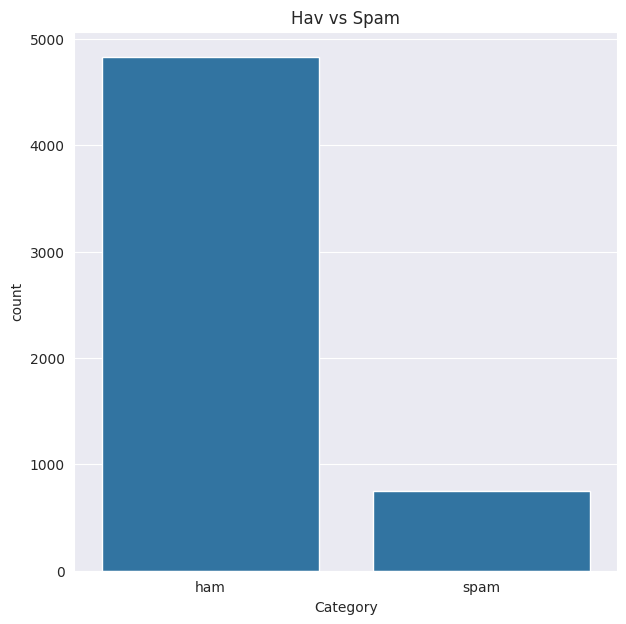

In [56]:
plt.figure(figsize=(7, 7))
sns.countplot(x='Category', data=df)
plt.title('Hav vs Spam')
plt.show()

In [67]:
x = df.get_column('Message')

y = df.get_column('Category')

In [61]:
from sklearn.preprocessing import LabelEncoder

In [62]:
encoder = LabelEncoder()
y = encoder.fit_transform(y)

In [64]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [65]:
vector = TfidfVectorizer(stop_words='english', max_features=3000)

In [68]:
x_vector = vector.fit_transform(x)

In [69]:
from sklearn.model_selection import train_test_split

In [70]:
x_train, x_test, y_train, y_test = train_test_split(x_vector, y, test_size=0.3, random_state=42, stratify=y)

In [71]:
from sklearn.naive_bayes import MultinomialNB

In [72]:
Model = MultinomialNB()

Model.fit(x_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [73]:
y_pred = Model.predict(x_test)

In [74]:
y_pred

array(['spam', 'ham', 'spam', ..., 'spam', 'ham', 'ham'],
      shape=(1672,), dtype='<U4')

In [75]:
from sklearn.metrics import accuracy_score

In [76]:
accuracy = accuracy_score(y_test, y_pred)
print(f"""The accuracy of the model is {accuracy*100:.2f}""")

The accuracy of the model is 97.37


In [77]:
from sklearn.metrics import classification_report

In [78]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         ham       0.97      1.00      0.99      1448
        spam       1.00      0.80      0.89       224

    accuracy                           0.97      1672
   macro avg       0.99      0.90      0.94      1672
weighted avg       0.97      0.97      0.97      1672



In [79]:
print(f"""Train Score : {Model.score(x_train,y_train) * 100:.2f}%""")
print(f"""Test Score : {Model.score(x_test,y_test) * 100:.2f}%""")

Train Score : 98.10%
Test Score : 97.37%
